## 06. Cross-matching the filament catalog with Planck and SPT
**Author**: Soumya Shreeram <br/>
**Date created**: 18th May 2022 <br/>
**Last edited**: tbu <br/>

In [29]:
# astropy modules
import astropy.units as u
import astropy.io.fits as fits

from astropy.table import Table, Column, join
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM, z_at_value

import numpy as np

# system imports
import os
import sys
import importlib as ib
import glob
import gzip
import copy

# plotting imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib import cm
import seaborn as sns
import pandas as pd

import healpy as hp
from healpy.newvisufunc import projview, newprojplot
from skimage.morphology import skeletonize
from skimage import data
from skimage.util import invert

In [2]:
import filaments as fo

In [3]:
%load_ext autoreload
%autoreload 2

In [88]:
mpl.rcParams['agg.path.chunksize'] = 100000
mpl.rcParams["font.family"] = "Times New Roman"
%matplotlib inline
font = { 'family': 'serif',
        'weight' : 'medium',
        'size'   : 20}
mpl.rc('font', **font)

bright_colors = sns.color_palette("bright")

In [5]:
base_dir = "/data53s/shreeram/Filament_stacking"
code_dir = f"{base_dir}/code"
image_dir = f"{base_dir}/images"
data_dir = f"{base_dir}/data/Cluster_catalogs"

### 1. Input parameters

In [62]:
z_low, z_high = 0.31, 0.32
z_range = (z_low, z_high)

# can change this default value in the class objects below
NSIDE = 256

val_erass1 = 1
val_act = val_erass1+1
val_psz = val_act+1
val_combined = val_psz+1
val_filament=val_combined+16

reso = hp.pixelfunc.nside2resol(NSIDE, arcmin=True)

In [7]:
cluster_cat_eRASS1 = fo.ClusterCatalogs(redshift_range=z_range)
cluster_cat_ACT = fo.ClusterCatalogs(this_cluster_cat_name='ACT', redshift_range=z_range)
cluster_cat_PSZ = fo.ClusterCatalogs(this_cluster_cat_name='PSZ', redshift_range=z_range)
cluster_cat_combined = fo.ClusterCatalogs(this_cluster_cat_name='combined', redshift_range=z_range)

# produce the healpy maps with discs around the clusters
eRASS1 = cluster_cat_eRASS1.get_healpy_clusters_map(fil_pixel_cluster_disc=val_erass1)
clu_map_eRASS1, clu_map_with_discs_eRASS1, clu_pix_idx_eRASS1 = eRASS1

ACT = cluster_cat_ACT.get_healpy_clusters_map(fil_pixel_cluster_disc= val_act)
clu_map_ACT, clu_map_with_discs_ACT, clu_pix_idx_ACT = ACT

PSZ = cluster_cat_PSZ.get_healpy_clusters_map(fil_pixel_cluster_disc= val_psz)
clu_map_PSZ, clu_map_with_discs_PSZ, clu_pix_idx_PSZ = PSZ

combined = cluster_cat_combined.get_healpy_clusters_map(fil_pixel_cluster_disc= val_combined)
clu_map_combined, clu_map_with_discs_combined, clu_pix_idx_combined = combined

INFO:ClusterCatalogs:Default cluster catalog set to `eRASS1`
INFO:ClusterCatalogs:Other options include: PSZ, ACT
INFO:ClusterCatalogs:Selecting in the redshift bin 0.31<z<0.32
INFO:ClusterCatalogs:Selecting in the redshift bin 0.31<z<0.32
INFO:ClusterCatalogs:Selecting in the redshift bin 0.31<z<0.32
INFO:ClusterCatalogs:catalogs in this file   srccat  
----------
    ACTDR5
      MCXC
      PSZ2
     RXGCC
    XCSDR1
    XClass
    XXL365
     eFEDS
  spt2500d
   spt_ecs
sptpol100d
INFO:ClusterCatalogs:Selecting in the redshift bin 0.31<z<0.32


<MollweideAxesSubplot:>

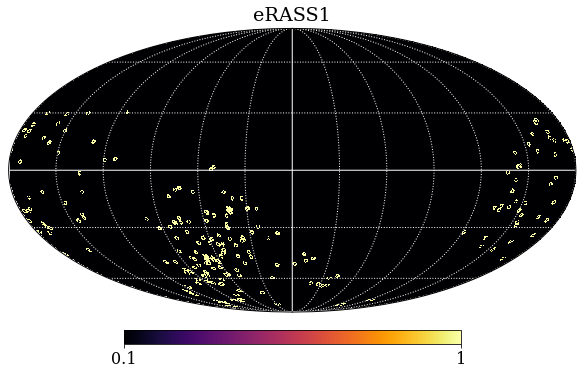

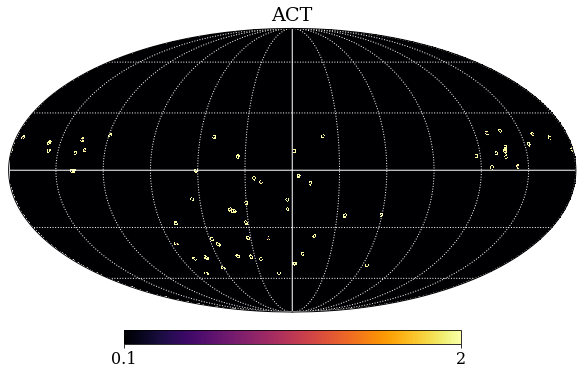

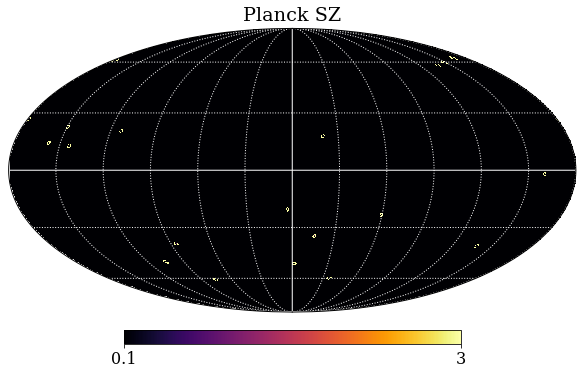

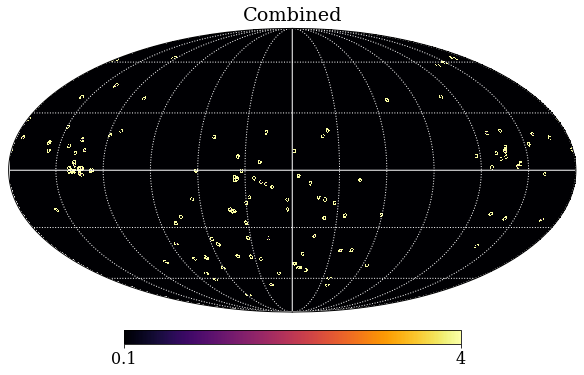

In [10]:
CMRmap = copy.copy(mpl.cm.get_cmap("CMRmap"))
inferno = copy.copy(mpl.cm.get_cmap("inferno"))

            
fo.healpy_mollview(clu_map_with_discs_eRASS1, cmap=inferno, title='eRASS1', norm=None)
fo.healpy_mollview(clu_map_with_discs_ACT, cmap=inferno, title='ACT')
fo.healpy_mollview(clu_map_with_discs_PSZ, cmap=inferno, title='Planck SZ')
fo.healpy_mollview(clu_map_with_discs_combined, cmap=inferno, title='Combined')

Load the filament catalog 

In [63]:
this_fil_duque21 = fo.Filaments(filament_catalogue_name='Duque_2021_SDSS')
plot_obj_duque21 = fo.DoPlotFilaments(this_fil_duque21)

# open the filament catalogue
fil_table, ra_og, dec_og = this_fil_duque21.open_fil_cat()
ra_fil, dec_fil = this_fil_duque21.choose_z_unc(fil_table=fil_table, ra_og=ra_og, dec_og=dec_og)

filament_map, fil_pix_idx = fo.produce_healpy_map(NSIDE, ra_fil, dec_fil, return_pixel_idx=True,
                                                 fil_val=val_filament)

INFO:Filaments:Default param 'which_redshifts=lowz'  


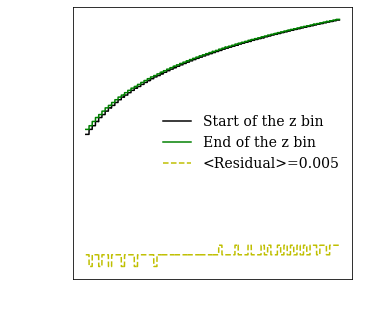

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(5,5))
ax.plot(fil_table['z_low'], 'k-', label='Start of the z bin')
ax.plot(fil_table['z_high'], 'g-', label='End of the z bin')

mean = np.mean(fil_table['z_high']-fil_table['z_low'])
ax.plot(fil_table['z_high']-fil_table['z_low'], 'y--', 
        label=f'<Residual>={mean:.3f}')

fo.set_as_white(ax)
ax.set_yscale('log')
fo.set_labels(ax, 'Number', 'Redshift')

<MollweideAxesSubplot:>

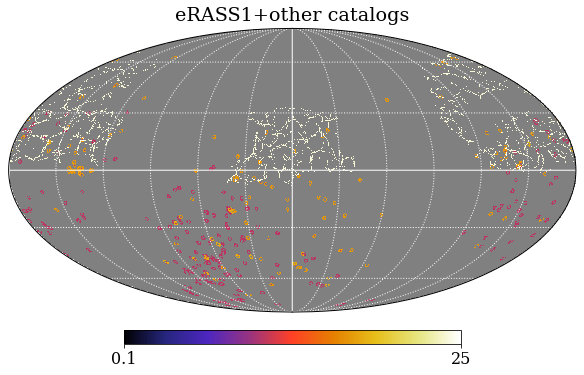

In [67]:
CMRmap = copy.copy(mpl.cm.get_cmap("CMRmap"))
inferno = copy.copy(mpl.cm.get_cmap("inferno"))
RdGy = copy.copy(mpl.cm.get_cmap("RdGy"))

all_cluster_maps = clu_map_with_discs_eRASS1+clu_map_with_discs_combined
fo.healpy_mollview(all_cluster_maps+filament_map, cmap=CMRmap, norm='log',
                   title='eRASS1+other catalogs')

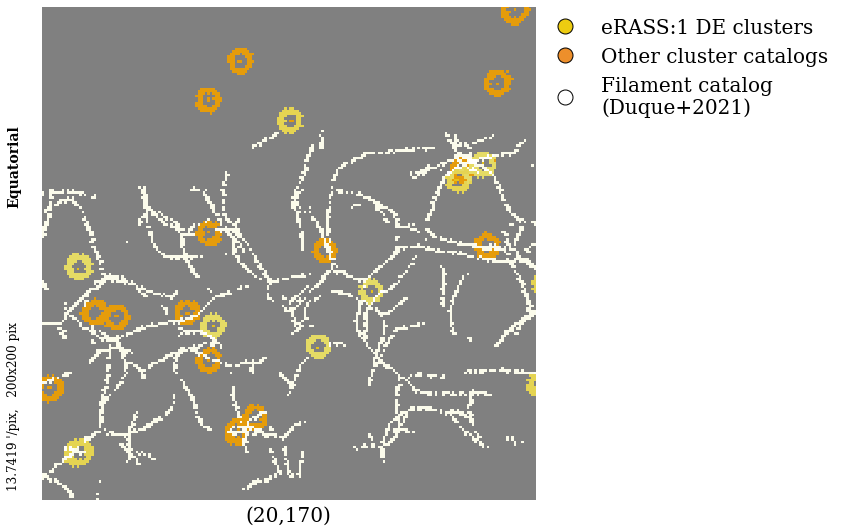

In [95]:
fig = plt.figure(figsize=(9,7))
ax = plt.subplot(111)

vmin, vmax =1e-3, np.max(filament_map+all_cluster_maps)
ax.axis('off')
cmap=CMRmap
norm = mpl.colors.Normalize(vmin=vmin, vmax=np.max(filament_map+all_cluster_maps))

center_ra, center_dec = 20, 170
hp.gnomview(filament_map+all_cluster_maps, 
            rot=[center_ra, center_dec, 0 ], fig=1,
            coord='C', unit='degrees', 
            xsize=200, ysize=200, nest=True, cmap=cmap, 
            norm='log', reso=reso, min=vmin, max=vmax,
            sub=(1, 1, 1), 
            bgcolor='w', cbar=False, title='',
            )
#title="Overlapping eRASS:1 with other catalogs\n",
            
labels=['eRASS:1 DE clusters', 'Other cluster catalogs', 'Filament catalog \n(Duque+2021)']
legend_elements = []

colors = ['#edcc11', 
          '#ed8f2b', 
          'w']
for c, l in zip(colors, labels):
    legend_elements.append(Line2D([0], [0], ls='', marker='o', color=c, label=l, mfc=c, ms=15, mec='k'))
ax.legend(handles=legend_elements, bbox_to_anchor=(1.6, 1.15), frameon=False)

fig.patch.set_facecolor('white')
fig.savefig(f'{image_dir}/zoomin_overlap_erass1.png', format='png')